In [18]:
import os, sys
from os.path import join as pjoin
import json
import pandas as pd
import numpy as np

root_dir = "/accounts/campus/austin.zane/stat-genie"

os.chdir(root_dir)
sys.path.insert(0, root_dir)

analysis_dir = pjoin(root_dir, "outputs", "analysis")
pairwise_eval_dir = pjoin(root_dir, "outputs", "pairwise_eval")


perturbation_mapping = {
    0: "add_features",
    1: "anonymize",
    2: "noperturb",
    3: "replace_with_rvs",
    4: "shuffle_names"
}

perturbation_to_int = {
    "add_features": 0,
    "anonymize": 1,
    "noperturb": 2,
    "replace_with_rvs": 3,
    "shuffle_names": 4
}

perturbations = perturbation_to_int.keys()
datasets = os.listdir(analysis_dir)

In [ ]:
for dataset in datasets:
    job_id = os.listdir(pjoin(pairwise_eval_dir, dataset))[0]
    with open(pjoin(pairwise_eval_dir, dataset, job_id, "pairwise_similarities.json"), "r") as f:
        pairwise_eval = json.load(f)

    print(dataset)
    diag_dict = {}

    for k_i, v_i in pairwise_eval.items():
        if k_i[0] != k_i[2]:
            continue
        i_list = []
        for k_j, v_j in v_i.items():
            if k_j[0] != k_j[2]:
                continue
            i_list.append(v_j['overall_similarity'])
            if v_j['overall_similarity'] < 5.0:
                print('Low score assiged to identical analyses: ', v_j['overall_similarity'])
        diag_dict[k_i] = i_list

reading
amtl
mortgage
caschools
hurricane
crofoot
affairs
fish
boxes


In [42]:
pairwise_eval

{'0_0': {'0_0': {'Independent Variables Similarity Score': 5,
   'Control Variables Similarity Score': 5,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 5,
   'conclusions': 5,
   'overall_similarity': 5.0},
  '0_1': {'Independent Variables Similarity Score': 5,
   'Control Variables Similarity Score': 4,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 4,
   'conclusions': 4,
   'overall_similarity': 4.4},
  '0_2': {'Independent Variables Similarity Score': 4,
   'Control Variables Similarity Score': 3,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 3,
   'conclusions': 1,
   'overall_similarity': 3.2},
  '0_3': {'Independent Variables Similarity Score': 4,
   'Control Variables Similarity Score': 4,
   'Response Variables Similarity Score': 5,
   'Model Similarity Score': 4,
   'conclusions': 1,
   'overall_similarity': 3.6},
  '0_4': {'Independent Variables Similarity Score': 5,
   'Control Variables Simi

In [50]:
# Create dataframe from pairwise evaluation JSON files
# Structure: outer keys 'i_j' = perturbation i vs perturbation j
#            inner keys 'k_l' = run k (from perturbation i) vs run l (from perturbation j)

rows = []

for dataset in datasets:
    job_id = os.listdir(pjoin(pairwise_eval_dir, dataset))[0]
    json_path = pjoin(pairwise_eval_dir, dataset, job_id, "pairwise_similarities.json")
    
    with open(json_path, "r") as f:
        pairwise_eval = json.load(f)
    
    # Parse the nested structure
    for pert_key, inner_dict in pairwise_eval.items():
        # Outer key: 'i_j' means perturbation i vs perturbation j
        parts_pert = pert_key.split('_')
        perturbation_i = int(parts_pert[0])
        perturbation_j = int(parts_pert[1])
        
        for run_key, scores_dict in inner_dict.items():
            # Inner key: 'k_l' means run k (from perturbation i) vs run l (from perturbation j)
            parts_run = run_key.split('_')
            run_i = int(parts_run[0])  # run from perturbation_i
            run_j = int(parts_run[1])  # run from perturbation_j
            
            # Extract scores
            row = {
                'dataset': dataset,
                'perturbation_i': perturbation_i,
                'perturbation_j': perturbation_j,
                'run_i': run_i,
                'run_j': run_j,
                'iv_score': scores_dict.get('Independent Variables Similarity Score'),
                'cv_score': scores_dict.get('Control Variables Similarity Score'),
                'model_score': scores_dict.get('Model Similarity Score'),
                'conclusion_score': scores_dict.get('conclusions'),
                'overall_score': scores_dict.get('overall_similarity')
            }
            rows.append(row)

# Create dataframe
df_pairwise = pd.DataFrame(rows)

# Add perturbation_pair_type column
def get_perturbation_pair_type(row):
    pert_i = row['perturbation_i']
    pert_j = row['perturbation_j']
    name_i = perturbation_mapping[pert_i]
    name_j = perturbation_mapping[pert_j]
    
    # Baseline is noperturb (perturbation 2)
    baseline_idx = 2
    
    if pert_i == pert_j:
        # Same perturbation (within perturbation)
        return f'within:{name_i}'
    elif pert_i == baseline_idx:
        # Baseline vs other perturbation
        return f'baseline_vs:{name_j}'
    elif pert_j == baseline_idx:
        # Other perturbation vs baseline
        return f'baseline_vs:{name_i}'
    else:
        # Different perturbations (neither is baseline)
        return f'between:{name_i}__{name_j}'

df_pairwise['perturbation_pair_type'] = df_pairwise.apply(get_perturbation_pair_type, axis=1)

print(f"Created dataframe with {len(df_pairwise)} rows")
print(df_pairwise.head())
print(f"\nPerturbation pair types:\n{df_pairwise['perturbation_pair_type'].value_counts()}")


Created dataframe with 2025 rows
   dataset  perturbation_i  perturbation_j  run_i  run_j  iv_score  cv_score  \
0  reading               0               0      0      0         5         5   
1  reading               0               0      0      1         5         4   
2  reading               0               0      0      2         5         4   
3  reading               0               0      0      3         5         5   
4  reading               0               0      0      4         5         4   

   model_score  conclusion_score  overall_score perturbation_pair_type  
0            5                 5            5.0    within:add_features  
1            4                 5            4.6    within:add_features  
2            3                 3            3.8    within:add_features  
3            5                 5            5.0    within:add_features  
4            4                 4            4.2    within:add_features  

Perturbation pair types:
within:add_features   

In [49]:
df_pairwise.loc[(df_pairwise['perturbation_i'] == df_pairwise['perturbation_j']) & (df_pairwise['run_i'] == df_pairwise['run_j'])]

,dataset,perturbation_i,perturbation_j,run_i,run_j,iv_score,cv_score,model_score,conclusion_score,overall_score
0,reading,0,0,0,0,5,5,5,5,5.0
5,reading,0,0,1,1,5,5,5,5,5.0
9,reading,0,0,2,2,5,5,5,5,5.0
12,reading,0,0,3,3,5,5,5,5,5.0
14,reading,0,0,4,4,5,5,5,5,5.0
...,...,...,...,...,...,...,...,...,...,...
2010,boxes,4,4,0,0,5,5,5,5,5.0
2015,boxes,4,4,1,1,5,5,5,5,5.0
2019,boxes,4,4,2,2,5,5,5,5,5.0
2022,boxes,4,4,3,3,5,5,5,5,5.0


In [53]:
print(df_pairwise.head())

   dataset  perturbation_i  perturbation_j  run_i  run_j  iv_score  cv_score  \
0  reading               0               0      0      0         5         5   
1  reading               0               0      0      1         5         4   
2  reading               0               0      0      2         5         4   
3  reading               0               0      0      3         5         5   
4  reading               0               0      0      4         5         4   

   model_score  conclusion_score  overall_score perturbation_pair_type  
0            5                 5            5.0    within:add_features  
1            4                 5            4.6    within:add_features  
2            3                 3            3.8    within:add_features  
3            5                 5            5.0    within:add_features  
4            4                 4            4.2    within:add_features  


In [ ]:
score_cols = [
    "iv_score",
    "cv_score",
    "model_score",
    "conclusion_score",
    # "overall_score",
]

long_df = df_pairwise.melt(
    id_vars=["dataset", "perturbation_pair_type"],
    value_vars=score_cols,
    var_name="step",
    value_name="score",
)

long_df["step"] = long_df["step"].str.replace("_score", "")


long_df["perturbation_pair_type"] = (
    long_df["perturbation_pair_type"].astype("category")
)
long_df["step"] = long_df["step"].astype("category")
long_df["dataset"] = long_df["dataset"].astype("category")


long_df["perturbation_pair_type"] = long_df["perturbation_pair_type"].astype("category")

baseline = "within:noperturb"

new_order = (
    [baseline] +
    [c for c in long_df["perturbation_pair_type"].cat.categories if c != baseline]
)

long_df["perturbation_pair_type"] = (
    long_df["perturbation_pair_type"]
    .cat.reorder_categories(new_order, ordered=False)
)


long_df["step"] = long_df["step"].astype("category")

step_ref = "conclusion"
step_order = (
    [step_ref] +
    [s for s in long_df["step"].cat.categories if s != step_ref]
)

long_df["step"] = long_df["step"].cat.reorder_categories(step_order, ordered=False)



In [75]:
long_df

,dataset,perturbation_pair_type,step,score
0,reading,within:add_features,iv,5
1,reading,within:add_features,iv,5
2,reading,within:add_features,iv,5
3,reading,within:add_features,iv,5
4,reading,within:add_features,iv,5
...,...,...,...,...
8095,boxes,within:shuffle_names,conclusion,5
8096,boxes,within:shuffle_names,conclusion,5
8097,boxes,within:shuffle_names,conclusion,5
8098,boxes,within:shuffle_names,conclusion,5


In [76]:
import statsmodels.formula.api as smf

model = smf.ols(
    "score ~ C(step) * C(perturbation_pair_type) + C(dataset)",
    data=long_df,
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     67.29
Date:                Tue, 13 Jan 2026   Prob (F-statistic):               0.00
Time:                        14:40:51   Log-Likelihood:                -10911.
No. Observations:                8100   AIC:                         2.196e+04
Df Residuals:                    8032   BIC:                         2.243e+04
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                                                                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [ ]:
# Create bar plots for coefficients with confidence intervals

import matplotlib.pyplot as plt
import numpy as np

coef_df = pd.DataFrame({
    'coef': model.params,
    'std_err': model.bse,
    'lower_ci': model.conf_int()[0],
    'upper_ci': model.conf_int()[1]
})

# Function to plot specific coefficients
def plot_coefficients(coef_names, title="Coefficients with 95% Confidence Intervals", figsize=(12, 6)):
    """
    Plot bar plots for specified coefficients with confidence intervals.
    
    Parameters:
    coef_names: list of coefficient names to plot 
    title: plot title
    figsize: figure size tuple
    """
    if isinstance(coef_names, str):
        coef_names = [coef_names]
    
    matching_coefs = []
    for name in coef_names:
        matches = [c for c in coef_df.index if name in c]
        matching_coefs.extend(matches)
    
    if not matching_coefs:
        print(f"No coefficients found matching: {coef_names}")
        return
    
    plot_data = coef_df.loc[matching_coefs].copy()
    plot_data = plot_data.sort_values('coef')
    
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(plot_data))
    
    colors = ['red' if x < 0 else 'blue' for x in plot_data['coef']]
    bars = ax.barh(y_pos, plot_data['coef'], color=colors, alpha=0.7)
    
    errors_lower = plot_data['coef'] - plot_data['lower_ci']
    errors_upper = plot_data['upper_ci'] - plot_data['coef']
    ax.errorbar(plot_data['coef'], y_pos, 
                xerr=[errors_lower, errors_upper],
                fmt='none', color='black', capsize=3, capthick=1.5)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=9)
    ax.set_xlabel('Coefficient Estimate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return plot_data


Main step effects (main effects only):


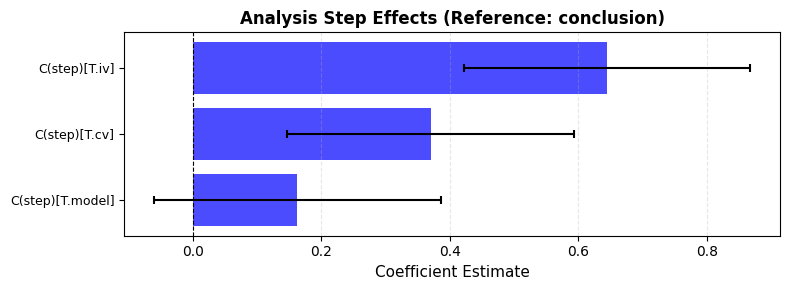

In [ ]:
# Updated plot_coefficients function that handles exact matches
def plot_coefficients(coef_names, title="Coefficients with 95% Confidence Intervals", figsize=(12, 6), color=None):
    """
    Plot bar plots for specified coefficients with confidence intervals.
    
    Parameters:
    coef_names: list of coefficient names to plot (exact names or partial matches)
    title: plot title
    figsize: figure size tuple
    color: color specification for bars. Can be:
        - None: uses red for negative, blue for positive coefficients
        - string: single color for all bars
        - list: colors for each bar (will cycle if shorter than number of bars)
    """

    if isinstance(coef_names, str):
        coef_names = [coef_names]
    

    matching_coefs = []
    for name in coef_names:

        if name in coef_df.index:
            matching_coefs.append(name)
        else:
            matches = [c for c in coef_df.index if name in c]
            matching_coefs.extend(matches)
    

    matching_coefs = list(dict.fromkeys(matching_coefs))
    
    if not matching_coefs:
        print(f"No coefficients found matching: {coef_names}")
        return
    
    plot_data = coef_df.loc[matching_coefs].copy()
    plot_data = plot_data.sort_values('coef')
    

    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(plot_data))
    
    if color is None:
        colors = ['red' if x < 0 else 'blue' for x in plot_data['coef']]
    elif isinstance(color, str):
        colors = color
    elif isinstance(color, (list, tuple, np.ndarray)):
        import itertools
        colors = list(itertools.islice(itertools.cycle(color), len(plot_data)))
    else:
        colors = ['red' if x < 0 else 'blue' for x in plot_data['coef']]
    
    bars = ax.barh(y_pos, plot_data['coef'], color=colors, alpha=0.7)
    
    errors_lower = plot_data['coef'] - plot_data['lower_ci']
    errors_upper = plot_data['upper_ci'] - plot_data['coef']
    ax.errorbar(plot_data['coef'], y_pos, 
                xerr=[errors_lower, errors_upper],
                fmt='none', color='black', capsize=3, capthick=1.5)
    
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data.index, fontsize=9)
    ax.set_xlabel('Coefficient Estimate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    return plot_data

# Helper function to get only main effects (no interactions)
def get_main_effects(pattern):
    """Get coefficients matching pattern but excluding interaction terms.
    Interaction terms have multiple 'C(' patterns, main effects have only one."""
    matches = [c for c in coef_df.index if pattern in c]
    # Filter out interaction terms: they have multiple 'C(' patterns
    main_effects = [c for c in matches if c.count('C(') == 1]
    return main_effects

# Plot only main step effects (no interactions)
print("Main step effects (main effects only):")
step_main_effects = get_main_effects('C(step)[T.')
step_coefs = plot_coefficients(step_main_effects, 
                                title="Analysis Step Effects (Reference: conclusion)",
                                figsize=(8, 3))

Perturbation pair type main effects (main effects only):


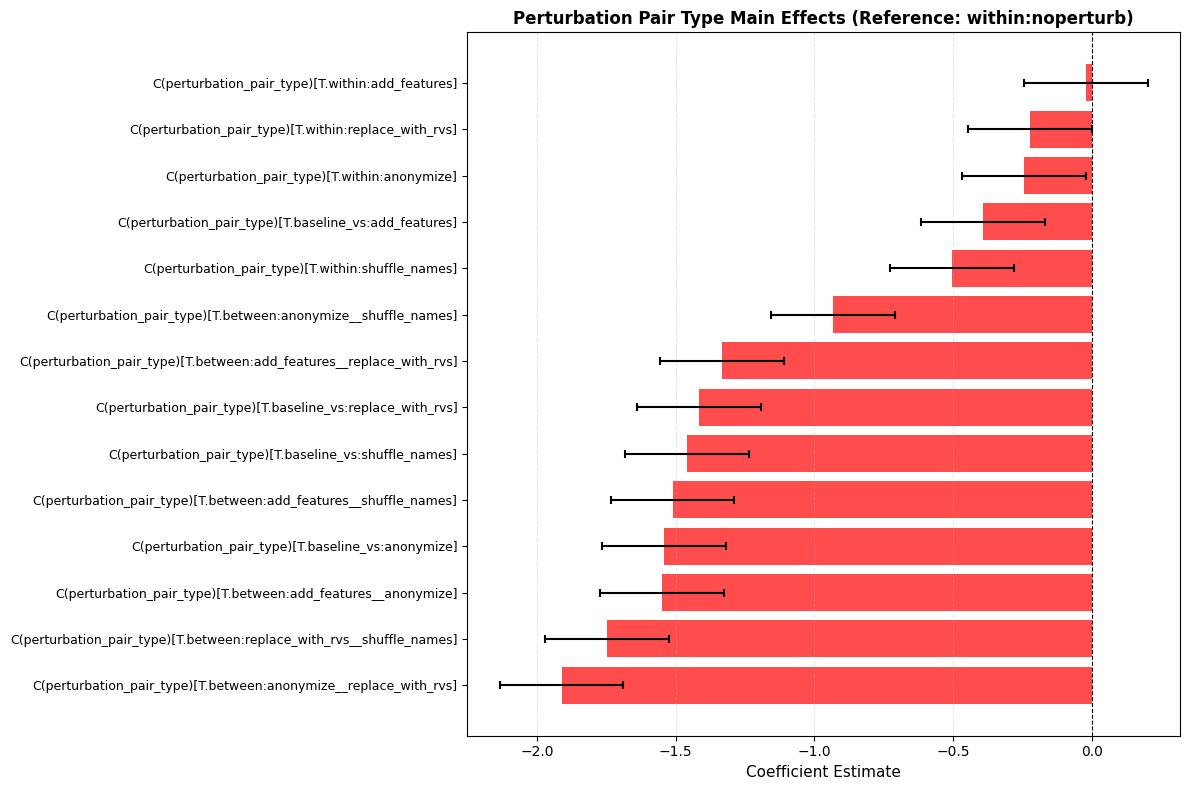

In [101]:
# Plot only perturbation pair type main effects (no interactions)
print("Perturbation pair type main effects (main effects only):")
pert_main_effects = get_main_effects('C(perturbation_pair_type)[T.')
pert_coefs = plot_coefficients(pert_main_effects, 
                                title="Perturbation Pair Type Main Effects (Reference: within:noperturb)",
                                figsize=(12, 8))

Perturbation pair type main effects (main effects only):


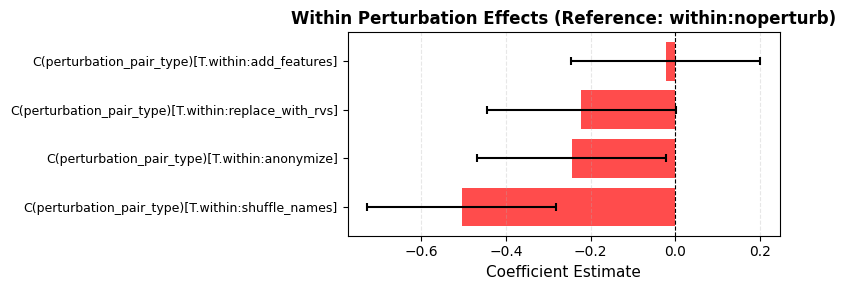

In [106]:
# Plot only perturbation pair type main effects (no interactions)
print("Perturbation pair type main effects (main effects only):")
pert_main_effects_within = get_main_effects('C(perturbation_pair_type)[T.within')
pert_coefs = plot_coefficients(pert_main_effects_within, 
                                title="Within Perturbation Effects (Reference: within:noperturb)",
                                figsize=(8, 3))

Perturbation pair type main effects (main effects only):


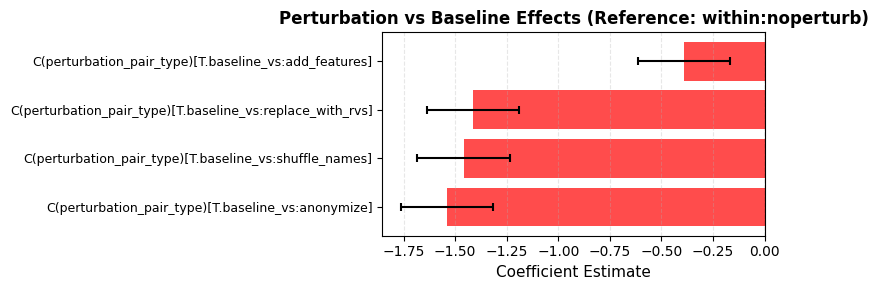

In [112]:
print("Perturbation pair type main effects:")
pert_main_effects_baseline_vs = get_main_effects('C(perturbation_pair_type)[T.baseline_vs')
pert_coefs = plot_coefficients(pert_main_effects_baseline_vs, 
                                title="Perturbation vs Baseline Effects (Reference: within:noperturb)",
                                figsize=(8, 3))

Perturbation pair type main effects (main effects only):


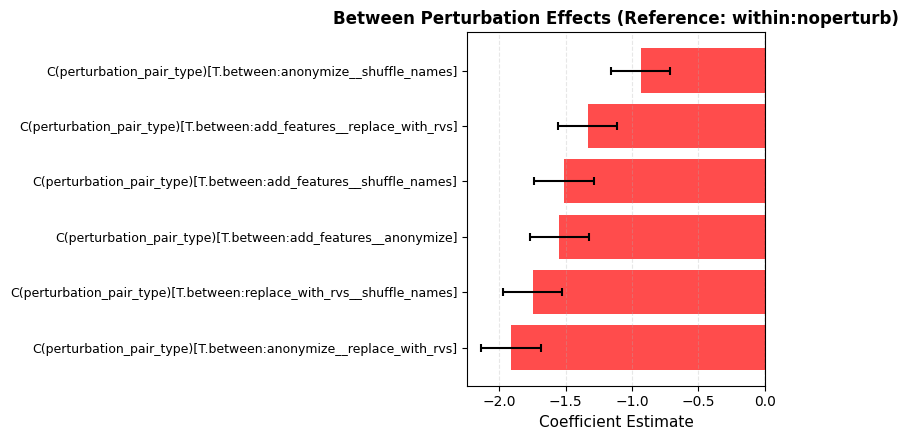

In [115]:
print("Perturbation pair type main effects:")
pert_main_effects_between = get_main_effects('C(perturbation_pair_type)[T.between')
pert_coefs = plot_coefficients(pert_main_effects_between, 
                                title="Between Perturbation Effects (Reference: within:noperturb)",
                                figsize=(8, 4.5))

# Heatmap

In [77]:
baseline = (
    long_df[long_df["perturbation_pair_type"] == "within:noperturb"]
    .groupby(["dataset", "step"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "baseline_score"})
)
merged = long_df.merge(
    baseline,
    on=["dataset", "step"],
    how="left"
)

merged["delta"] = merged["score"] - merged["baseline_score"]

heatmap_df = (
    merged.groupby(["step", "perturbation_pair_type"])["delta"]
    .mean()
    .unstack()
)

mask = heatmap_df.columns.str.startswith("between")
heatmap_df_filtered = heatmap_df.loc[:, ~mask]



In [78]:
print(heatmap_df_filtered)

perturbation_pair_type  within:noperturb  baseline_vs:add_features  \
step                                                                 
conclusion                  3.289550e-18                 -0.392593   
cv                          1.842148e-16                 -0.518519   
iv                         -2.631640e-17                 -0.118519   
model                       3.947460e-17                 -0.407407   

perturbation_pair_type  baseline_vs:anonymize  baseline_vs:replace_with_rvs  \
step                                                                          
conclusion                          -1.540741                     -1.414815   
cv                                  -0.281481                     -0.185185   
iv                                  -0.096296                     -0.133333   
model                               -0.488889                     -0.362963   

perturbation_pair_type  baseline_vs:shuffle_names  within:add_features  \
step                          

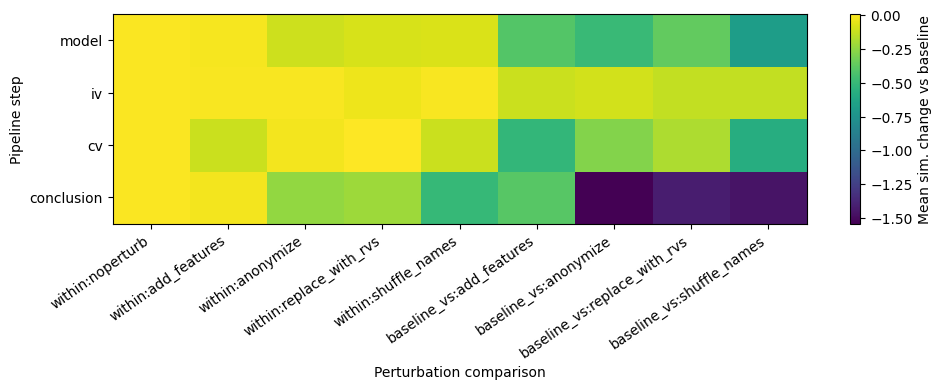

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

desired_order = [
    'within:noperturb', 'within:add_features',
    'within:anonymize', 'within:replace_with_rvs',
    'within:shuffle_names', 'baseline_vs:add_features',
    'baseline_vs:anonymize', 'baseline_vs:replace_with_rvs',
    'baseline_vs:shuffle_names'
]

heatmap_df_filtered = heatmap_df_filtered[desired_order]

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(
    heatmap_df_filtered.values,
    aspect="auto",
    origin="lower",
)

ax.set_xticks(np.arange(heatmap_df_filtered.shape[1]))
ax.set_yticks(np.arange(heatmap_df_filtered.shape[0]))

ax.set_xticklabels(heatmap_df_filtered.columns, rotation=35, ha="right")
ax.set_yticklabels(heatmap_df_filtered.index)

ax.set_xlabel("Perturbation comparison")
ax.set_ylabel("Pipeline step")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean sim. change vs baseline")

plt.tight_layout()
plt.show()
